In [2]:
import requests
from io import StringIO
import pandas as pd

In [4]:
df = pd.read_csv(StringIO(requests.get('https://raw.githubusercontent.com/nicolelumagui/ML-Exercise_Advertising_Linear-Regression/refs/heads/master/IPYNB%20and%20Dataset/Advertising.csv').text))
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df = df.drop(columns='Unnamed: 0')

In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.sample(5)

,TV,Radio,Newspaper,Sales
160,172.5,18.1,30.7,14.4
56,7.3,28.1,41.4,5.5
81,239.8,4.1,36.9,12.3
128,220.3,49.0,3.2,24.7
33,265.6,20.0,0.3,17.4


In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

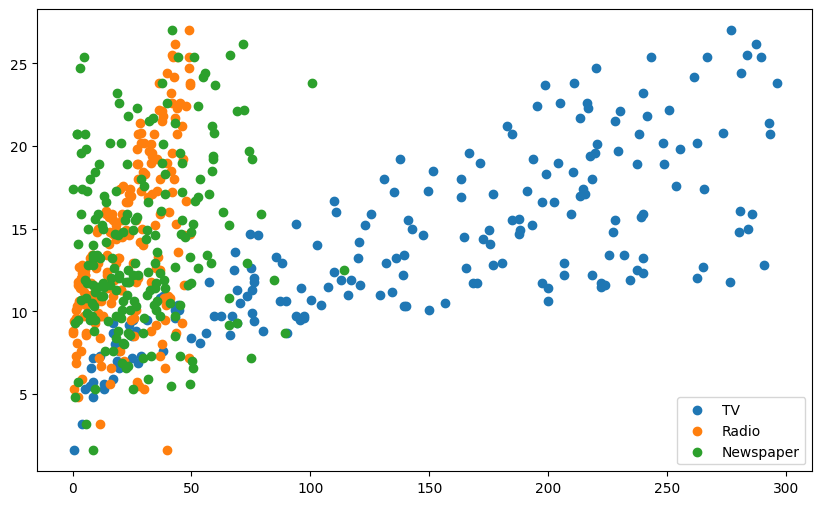

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['TV'], df['Sales'], label='TV')
plt.scatter(df['Radio'], df['Sales'], label='Radio')
plt.scatter(df['Newspaper'], df['Sales'], label='Newspaper')
plt.legend()
plt.show()

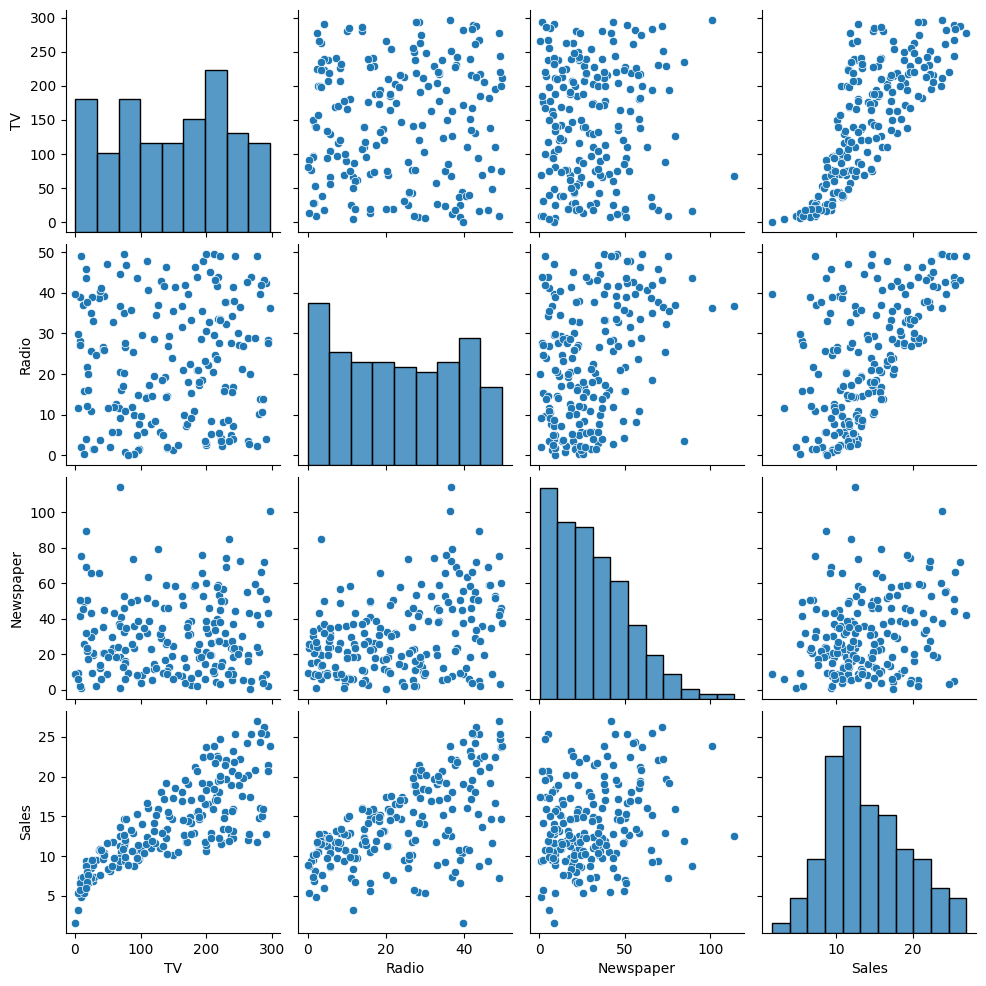

In [16]:
sns.pairplot(df)
plt.show()

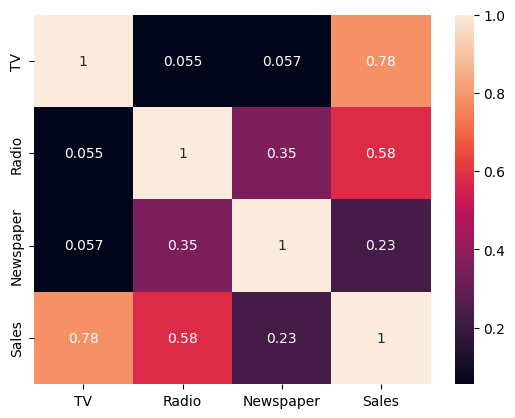

In [20]:
sns.heatmap(df.corr(), annot=True)
plt.show()

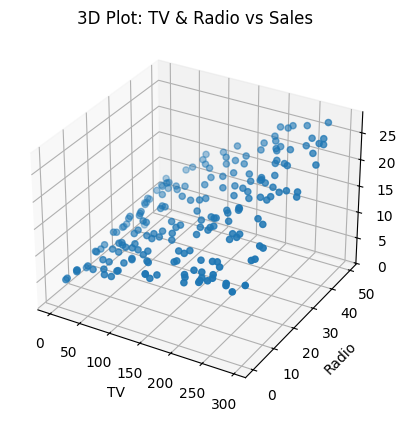

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['TV'], df['Radio'], df['Sales'])
ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")

plt.title("3D Plot: TV & Radio vs Sales")
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,:3], df.iloc[:, 3], test_size=0.2, random_state=42)

In [39]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
cross_val_score(lr, df.iloc[:,:3], df.iloc[:,3], cv=5, scoring='r2').mean()

np.float64(0.8871063495438435)

In [49]:
r2_score(y_test, lr.predict(x_test))

0.899438024100912